In [22]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle as pkl
import json

In [ ]:
#df_Nfd = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/total_mzcounts_sorted.csv')
df_new = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/new_data_MZB.csv')
df_ont = pd.read_csv('/home/apoorva/Desktop/work/MZ_analysis/data/New_data/ontogeny_counts.csv')


file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/TDM_T1_varyinflux.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/new_mzontogeny.fitall.varyinflux.T1.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_fitall = pkl.load(f)
else:
    raise EOFError("File is empty")
#Open json file
with open('/home/apoorva/Desktop/work/MZ_analysis/data/Mz_ontogenyT1.varyinginflux.json') as f:
    data = json.load(f)

/tmp/ipykernel_425052/3935600550.py:17: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


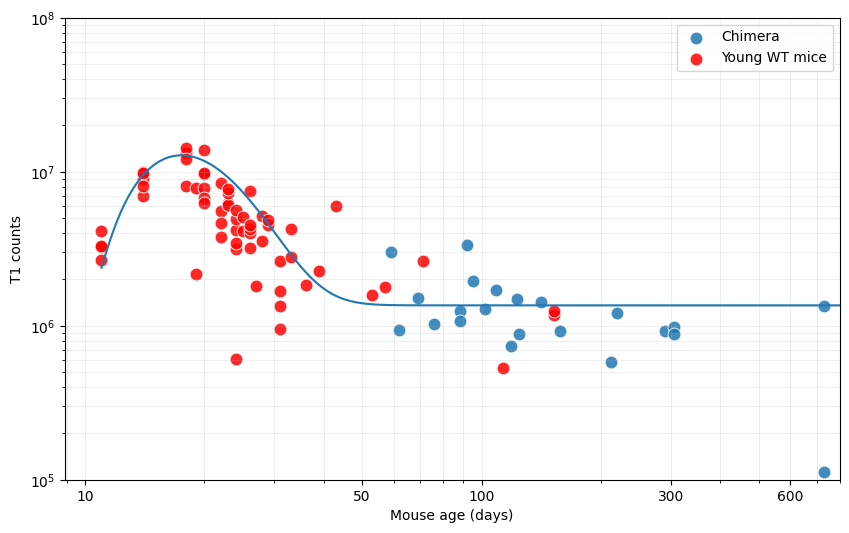

In [24]:
def P(t):
    theta_0 = np.exp(14.12)
    nu = 0.28
    n = 2.1
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
    

# Plot T1 AA4.1 counts

fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_T1_AA4.1+', alpha=0.85 ,s=85, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='T1 AA4.1+_total', alpha=0.85, s=85, color = 'Red',label='Young WT mice', legend=False)
plt.plot(np.arange(11, 800, 0.05), P(np.arange(11, 800, 0.05)))
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e5, 1e8)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 50,  100, 300, 600], [10, 50, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('T1 counts')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


In [25]:
def P(t):
    # theta_0 = np.exp(14.17)
    # nu = 0.31
    # n = 1.98
    theta_0 = np.exp(14.12)
    nu = 0.28
    n = 2.1
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi(t):
    r_phi = data_neutral.stan_variable('r_d')  # Extract 'r_d' from CmdStanMCMC object
    phi = data_neutral.stan_variable('phi')  # Extract 'phi' from CmdStanMCMC object
    phi_var = phi / (1 + np.exp(-r_phi * (t - 30)))
    # phi_var = phi * np.exp(-r_phi * (t - 40))
    return phi_var

# Define the ODE function
def ode_function(t, M, phi, rho, delta, P):
    dMdt = phi(t) * P(t) + rho* M - delta * M
    return np.array(dMdt) 


# Define the parameters as array
# lamda = np.mean(data_neutral.delta) - np.mean(data_neutral.rho)
rho = data_neutral.rho
delta = data_neutral.delta
print("rphi", np.mean(data_neutral.r_d))


#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

phi_values = data_neutral.stan_variable('phi')  # Extract 'phi' values from CmdStanMCMC object
r_phi_values = data_neutral.stan_variable('r_d')  # Extract 'r_d' values from CmdStanMCMC object

sol = np.zeros((len(phi_values), len(t_ev)))
for i in range(len(phi_values)):
    def phi_func(t):
        return phi_values[i] / (1 + np.exp(-r_phi_values[i] * (t - 30)))
    
    result = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi_func, rho[i], delta[i], P))
    sol[i, :] = result.y[0]

# sol = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi, rho, delta, P))
# print(sol.y)

# sol = np.zeros((len(data_neutral.phi), len(t_ev)))
# for i in range(len(data_neutral.phi)):
#     result = solve_ivp(ode_function, [40, 750], M0, t_eval= t_ev, args=(phi[i], rho[i], delta[i], P))
#     sol[i, :] = result.y[0]

# print(sol.shape)
# print(M0)



rphi 0.037868489384133334


/tmp/ipykernel_425052/1994465230.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


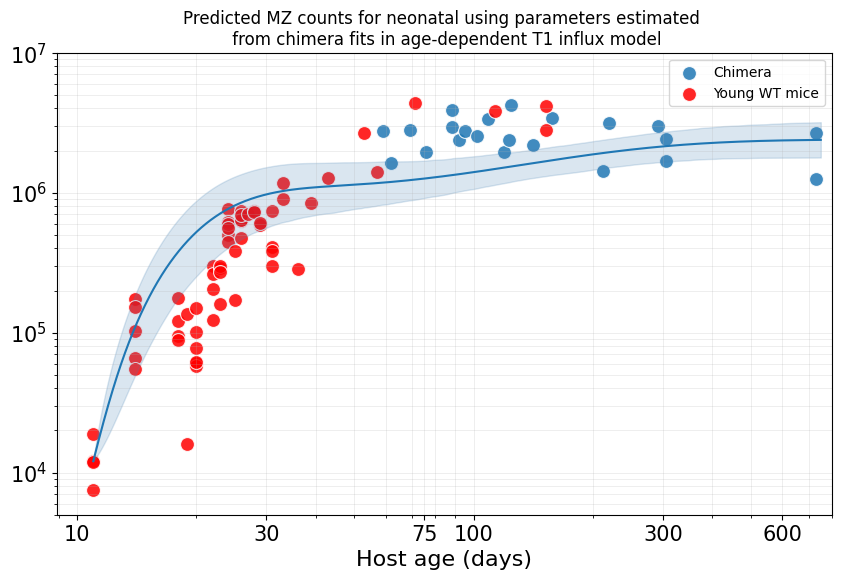

In [26]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
# plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
plt.plot(t_ev, np.mean(sol, axis=0))
plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=16)
plt.ylabel('')
plt.tick_params(axis='both', labelsize=15)
plt.title('Predicted MZ counts for neonatal using parameters estimated \n from chimera fits in age-dependent T1 influx model')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

/tmp/ipykernel_425052/263302346.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


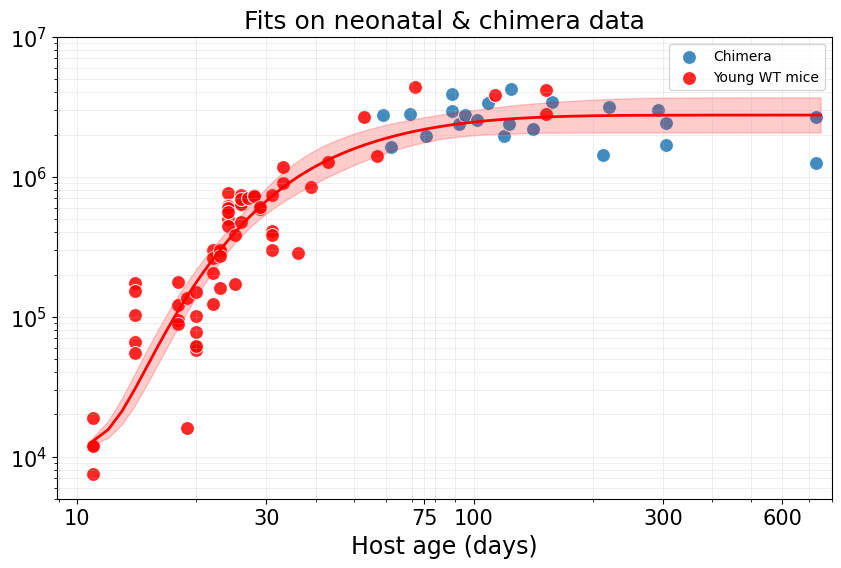

In [27]:
ts2= np.arange(11, 750, 1)

# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
plt.plot(ts2, np.mean(data_fitall.MZ_counts_pred, axis=0), color='red', linewidth=2)
plt.fill_between(ts2, np.quantile(data_fitall.MZ_counts_pred, 0.025, axis=0), np.quantile(data_fitall.MZ_counts_pred, 0.975, axis=0), alpha=0.2, color='red')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Host age (days)', fontsize=17)
plt.ylabel('')
plt.tick_params(axis='both', labelsize=15)
plt.title('Fits on neonatal & chimera data', fontsize=18)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

/tmp/ipykernel_425052/2763449848.py:14: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(0, 800)


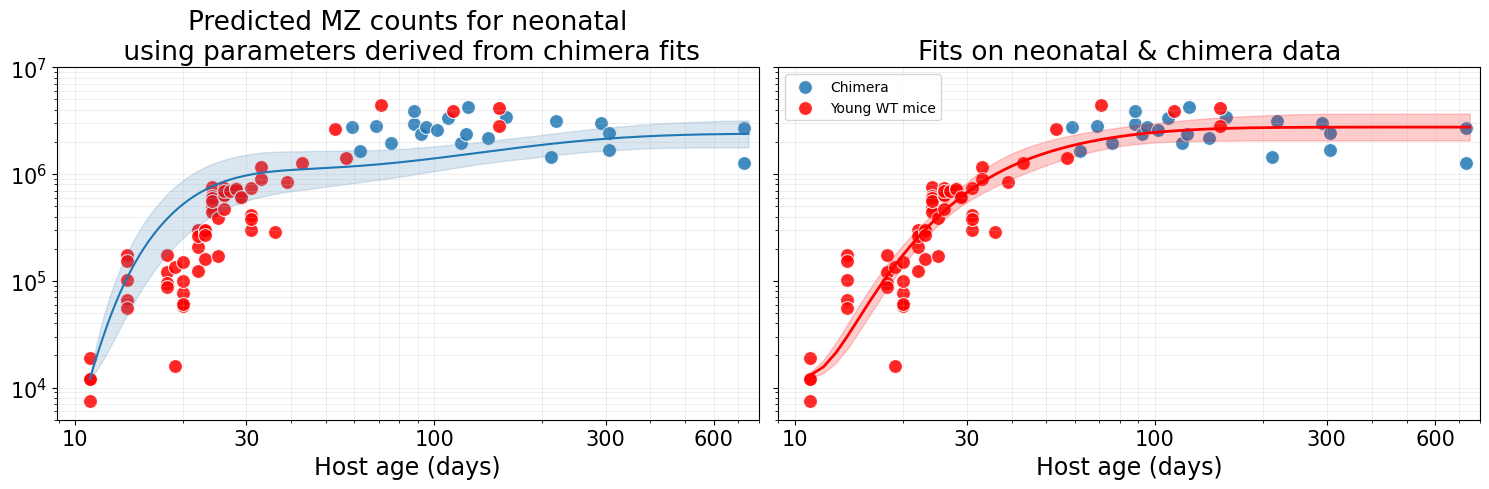

In [28]:
# Plot the Mz counts

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax1 = axes[0]
ax2 = axes[1] 

sns.scatterplot(ax=ax1, data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85, s=100, label='Chimera', legend=False)
sns.scatterplot(ax=ax1, data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
ax1.plot(t_ev, np.mean(sol, axis=0), label='Predicted trajectory')
ax1.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color='steelblue', alpha=0.2)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylim(5 * 1e3, 1e7)
ax1.set_xlim(0, 800)
ax1.set_xticks([10, 30,100, 300, 600])
ax1.set_xticklabels([10, 30, 100, 300, 600])
ax1.set_xlabel('Host age (days)', fontsize=17)
ax1.set_ylabel('')
ax1.set_title('Predicted MZ counts for neonatal\n using parameters derived from chimera fits', fontsize=19)
ax1.tick_params(axis='both', labelsize=15) 
ax1.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# ax1.legend()

ts2= np.arange(11, 750, 1)

# Plot the Mz counts
sns.scatterplot(ax=ax2, data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85, s=100, label='Chimera', legend=False)
sns.scatterplot(ax=ax2, data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
ax2.plot(ts2, np.mean(data_fitall.MZ_counts_pred, axis=0), color='red', linewidth=2)
ax2.fill_between(ts2, np.quantile(data_fitall.MZ_counts_pred, 0.025, axis=0), np.quantile(data_fitall.MZ_counts_pred, 0.975, axis=0), alpha=0.2, color='red')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylim(5 * 1e3, 1e7)
ax2.set_xlim(9, 800)
ax2.set_xticks([10, 30, 100, 300, 600])
ax2.set_xticklabels([10, 30, 100, 300, 600])
ax2.set_title('Fits on neonatal & chimera data', fontsize=19)
ax2.set_xlabel('Host age (days)', fontsize=17)
ax2.set_ylabel('')
ax2.set_yticklabels([])
ax2.tick_params(axis='both', labelsize=15) 
ax2.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
ax2.legend()

plt.tight_layout()

plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/MZ_counts_ontogeny.png', dpi=350, bbox_inches='tight')



1500
Daily influx in busulfan chimeras


/tmp/ipykernel_425052/1268254081.py:44: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 800)


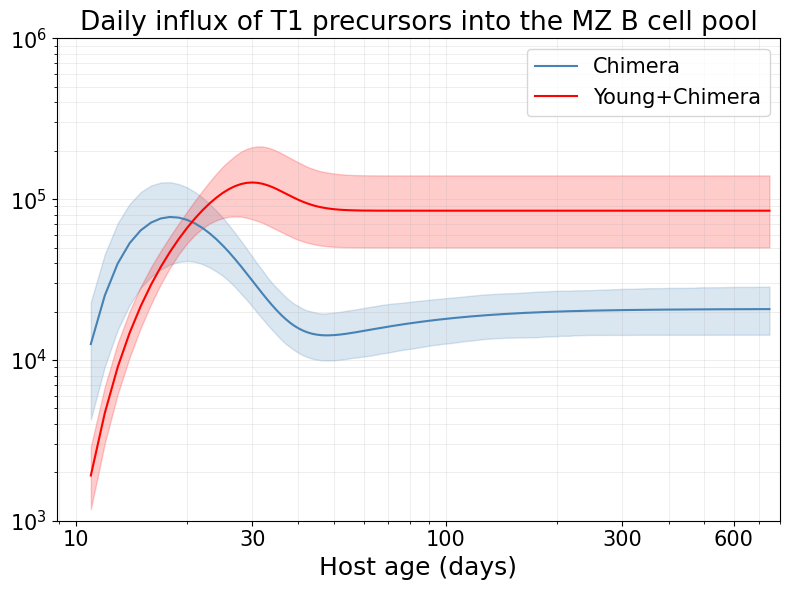

In [29]:
print(len(data_neutral.phi))


t_ev = np.arange(11, 750, 1)
# Compute daily influx in busulfan chimeras
def P(t):
    theta_0 = np.exp(14.12)
    nu = 0.28
    n = 2.1
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi1(t):
    r_phi = data_neutral.stan_variable('r_d') # Extract 'r_d' from CmdStanMCMC object
    phi = data_neutral.stan_variable('phi') # Extract 'phi' from CmdStanMCMC object
    phi_var = phi / (1 + np.exp(-r_phi * (t - 30)))
    return phi_var

def phi2(t):
    r_phi = data_fitall.stan_variable('r_phi') # Extract 'r_d' from CmdStanMCMC object
    phi = data_fitall.stan_variable('phi') # Extract 'phi' from CmdStanMCMC object
    phi_var = phi / (1 + np.exp(-r_phi * (t - 30)))
    return phi_var

daily_influx_b = np.zeros((len(data_neutral.stan_variable('phi')), len(t_ev)))
for i in range(0, len(t_ev)):
    daily_influx_b[:,i] = phi1(t_ev[i]) * P(t_ev[i])
    
print("Daily influx in busulfan chimeras")

daily_influx_o = np.zeros((len(data_fitall.stan_variable('phi')), len(t_ev)))
for i in range(0, len(t_ev)):
    daily_influx_o[:,i] = phi2(t_ev[i]) * P(t_ev[i])
    
#Plot daily influxes in one plot

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(t_ev, np.mean(daily_influx_b, axis=0), label='Chimera', color='steelblue')
ax.fill_between(t_ev, np.quantile(daily_influx_b, 0.025, axis=0), np.quantile(daily_influx_b, 0.975, axis=0), color='steelblue', alpha=0.2)
ax.plot(t_ev, np.mean(daily_influx_o, axis=0), label='Young+Chimera', color='red')
ax.fill_between(t_ev, np.quantile(daily_influx_o, 0.025, axis=0), np.quantile(daily_influx_o, 0.975, axis=0), color='red', alpha=0.2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e3, 1e6)
ax.set_xlim(0, 800)
ax.set_xticks([10, 30, 100, 300, 600])
ax.set_xticklabels([10, 30, 100, 300, 600])
ax.set_xlabel('Host age (days)', fontsize=18)
ax.set_ylabel('')
ax.set_title('Daily influx of T1 precursors into the MZ B cell pool', fontsize=19)
ax.tick_params(axis='both', labelsize=15)
ax.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
ax.legend(fontsize=15, loc='upper right')
plt.tight_layout()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/daily_influx_ontogeny.png', dpi=350, bbox_inches='tight')


1500


/tmp/ipykernel_425052/431418503.py:54: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 800)


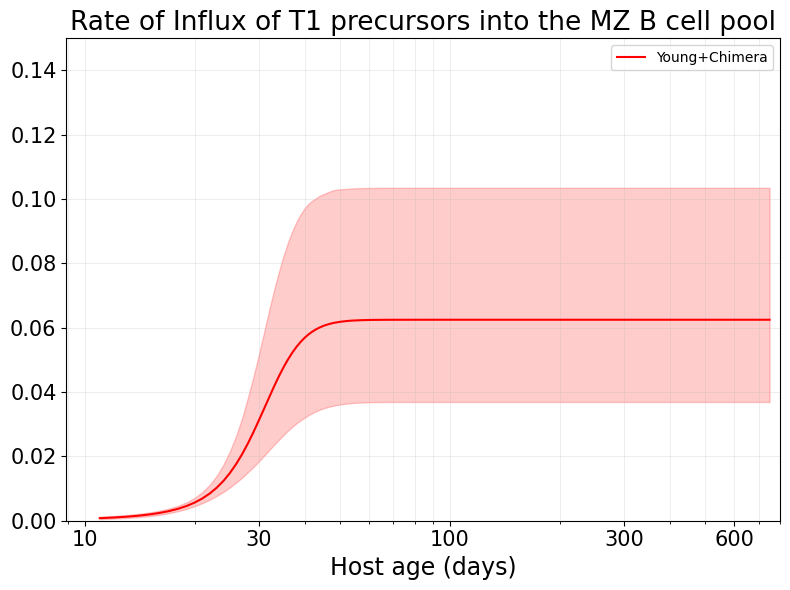

In [30]:
print(len(data_neutral.phi))


t_ev = np.arange(11, 750, 1)
# Compute daily influx in busulfan chimeras
def P(t):
    theta_0 = np.exp(14.12)
    nu = 0.28
    n = 2.1
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi1(t):
    r_phi = data_neutral.stan_variable('r_d') # Extract 'r_d' from CmdStanMCMC object
    phi = data_neutral.stan_variable('phi') # Extract 'phi' from CmdStanMCMC object
    phi_var = phi / (1 + np.exp(-r_phi * (t - 30)))
    return phi_var

def phi2(t):
    r_phi = data_fitall.stan_variable('r_phi') # Extract 'r_d' from CmdStanMCMC object
    phi = data_fitall.stan_variable('phi') # Extract 'phi' from CmdStanMCMC object
    phi_var = phi / (1 + np.exp(-r_phi * (t - 30)))
    return phi_var

influx_rate_b = np.zeros((len(data_neutral.stan_variable('phi')), len(t_ev)))
for i in range(0, len(t_ev)):
    influx_rate_b[:,i] = phi1(t_ev[i]) 
    
influx_rate_o = np.zeros((len(data_fitall.stan_variable('phi')), len(t_ev)))
for i in range(0, len(t_ev)):
    influx_rate_o[:,i] = phi2(t_ev[i])

# daily_influx_b = np.zeros((len(data_neutral.stan_variable('phi')), len(t_ev)))
# for i in range(0, len(t_ev)):
#     daily_influx_b[:,i] = phi1(t_ev[i]) * P(t_ev[i])
    
# print("Daily influx in busulfan chimeras")

# daily_influx_o = np.zeros((len(data_fitall.stan_variable('phi')), len(t_ev)))
# for i in range(0, len(t_ev)):
#     daily_influx_o[:,i] = phi2(t_ev[i]) * P(t_ev[i])
    
#Plot daily influxes in one plot

fig, ax = plt.subplots(figsize=(8,6))
# ax.plot(t_ev, np.mean(influx_rate_b, axis=0), label='Chimera', color='steelblue')
# ax.fill_between(t_ev, np.quantile(influx_rate_b, 0.025, axis=0), np.quantile(influx_rate_b, 0.975, axis=0), color='steelblue', alpha=0.2)
ax.plot(t_ev, np.mean(influx_rate_o, axis=0), label='Young+Chimera', color='red')
ax.fill_between(t_ev, np.quantile(influx_rate_o, 0.025, axis=0), np.quantile(influx_rate_o, 0.975, axis=0), color='red', alpha=0.2)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_ylim(0,0.15)
# ax.set_yticks([0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15])
# ax.set_yticklabels([0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15])
ax.set_xlim(0, 800)
ax.set_xticks([10, 30, 100, 300, 600])
ax.set_xticklabels([10, 30, 100, 300, 600])
ax.set_xlabel('Host age (days)', fontsize=17)
ax.set_ylabel('')
ax.set_title('Rate of Influx of T1 precursors into the MZ B cell pool', fontsize=19)
ax.tick_params(axis='both', labelsize=15)
ax.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/influx_rate_ontogeny.png', dpi=350, bbox_inches='tight')


    


[26.77256957 25.0907557  29.70647749 ... 17.24165227 17.68390495
 17.14743117]


ValueError: 'x' and 'y' must have the same size

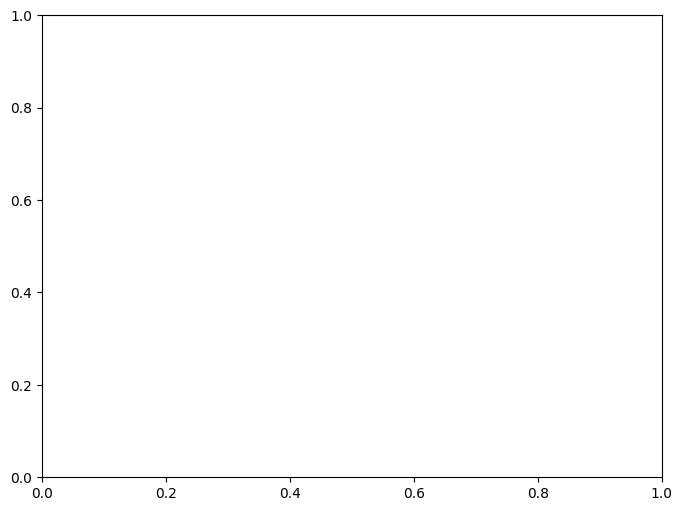

In [ ]:
# Calculate clonal half-life for ontogeny predictions 
'''clonallife = np.log(2) * (1/ data_fitall.stan_variable('lambda'))
print(clonallife)

# Plot error bars for clonal half-life
fig, ax = plt.subplots(figsize=(8,6))
ax.errorbar(np.arange(1, len(clonallife)+1), np.mean(clonallife, axis=0), yerr=np.std(clonallife, axis=0), fmt='o', color='red', label='Young+Chimera')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels([1, 2, 3, 4, 5])
ax.set_xlabel('Clonal half-life', fontsize=17)
ax.set_ylabel('Clonal half-life (days)', fontsize=17)
ax.set_title('Clonal half-life for ontogeny predictions', fontsize=19)
ax.tick_params(axis='both', labelsize=15)
ax.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
ax.legend()
plt.tight_layout()'''



[26.77256957 25.0907557  29.70647749 ... 17.24165227 17.68390495
 17.14743117]


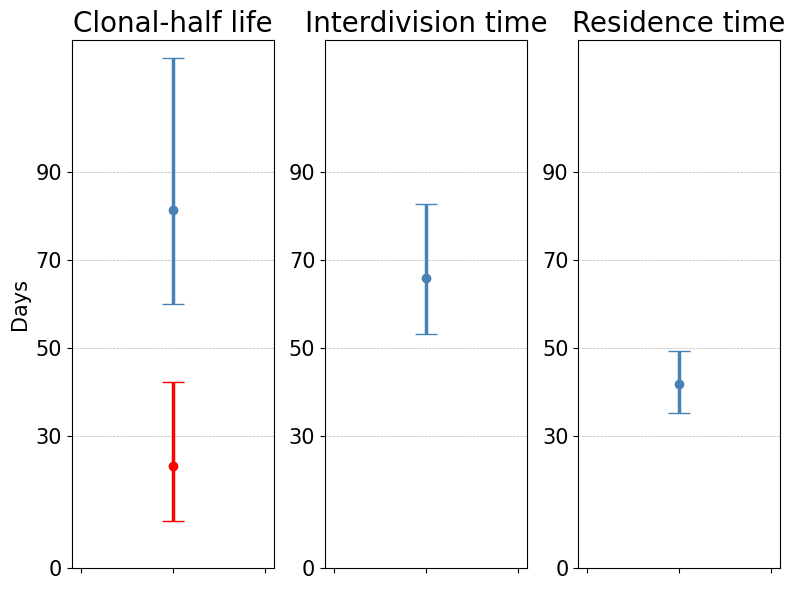

<Figure size 640x480 with 0 Axes>

In [34]:
# Calculate clonal half-life for ontogeny predictions
clonallife = np.log(2) * (1/ data_fitall.stan_variable('lambda'))
print(clonallife)

#plot error bar for clonal half-life



# Plot error plot for interdivision, clonal half-life , residence time

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=8, markersize=6, elinewidth=2.5)
    # ax.set_xlabel('Index', fontsize=12)
    # ax.set_ylabel(label, fontsize=12)
    ax.set_ylim(0, 120)
    ax.set_yticks([0,30, 50, 70, 90])
    ax.set_yticklabels([0,30, 50, 70, 90], fontsize=15)
    ax.set_xticklabels([])
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(8, 6))

# Plot rho_inv
plot_with_error_bars(data_neutral.rho_inv, 'rho_inv', 'steelblue', axes[1])


# Plot lamda_inv
plot_with_error_bars(data_neutral.lamda_inv, 'lamda_inv', 'steelblue', axes[0])
plot_with_error_bars(clonallife, 'clonal_half_life', 'red', axes[0])

axes[0].set_ylabel('Days', fontsize=15)
# axes[0].set_xlabel('Index', fontsize=8)
# axes[0].legend(['Chimera', 'Young+Chimera'], fontsize=6)
axes[1].set_title('Interdivision time', fontsize=20)
axes[0].set_title('Clonal-half life', fontsize=20)
axes[2].set_title('Residence time', fontsize=20)

# Plot delta_inv
plot_with_error_bars(data_neutral.delta_inv, 'delta_inv', 'steelblue', axes[2])

# Adjust layout
plt.tight_layout()
plt.show()

#save the figure
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/ontogeny_clonalhalf_life.png', dpi=350, bbox_inches='tight')

In [ ]:
def P(t):
    # theta_0 = np.exp(14.17)
    # nu = 0.31
    # n = 1.98
    theta_0 = np.exp(14.12)
    nu = 0.28
    n = 2.1
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi(t):
    r_phi = np.mean(data_neutral.r_d)
    phi = np.mean(data_neutral.phi)
    phi_var =  phi / (1 + np.exp(-r_phi * (t-30)))
    # phi_var = phi*np.exp(-r_phi*(t-40))
    return phi_var

# Define the ODE function
def ode_function(t, M, phi, rho, delta, P):
    dMdt = phi(t) * P(t) + rho* M - delta * M
    return np.array(dMdt) 


# Define the parameters as array
# lamda = np.mean(data_neutral.delta) - np.mean(data_neutral.rho)
rho = np.mean(data_neutral.rho)
delta = np.mean(data_neutral.delta)
print("rphi", np.mean(data_neutral.r_d))


#Initial conditions at time t=11
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)

sol = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi, rho, delta, P))
print(sol.y)

rphi 0.037868489384133334
[[  12058.           12069.88280835   12081.77521285 ... 2383905.24555551
  2383905.27799262 2383905.31042945]]


/tmp/ipykernel_425052/4249432543.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


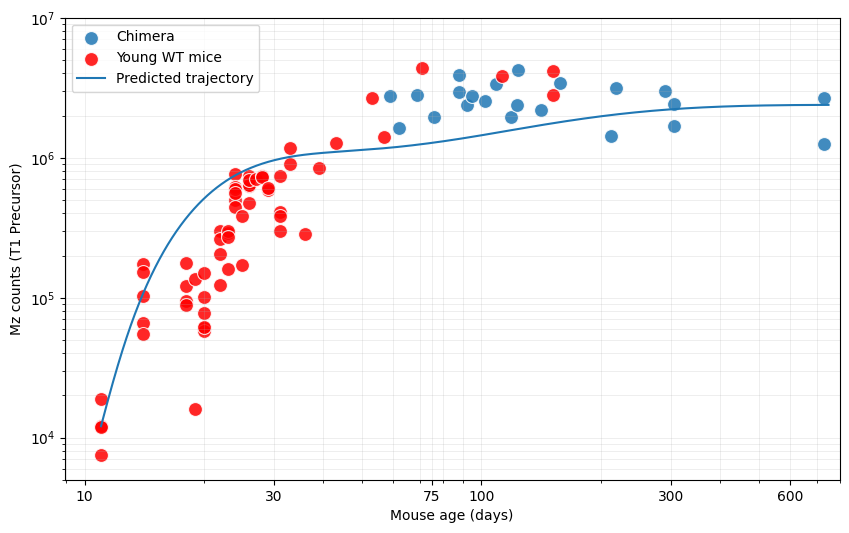

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color= 'Red',label='Young WT mice', legend=False)
plt.plot(t_ev, sol.y[0], label='Predicted trajectory')
# plt.plot(t_ev, npsol, axis=0), label='Predicted trajectory')
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
# plt.fill_between(t_ev, np.quantile(sol, 0.025, axis=0), np.quantile(sol, 0.975, axis=0), color = 'steelblue',alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 75, 100, 300, 600], [10, 30, 75, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# Calculate Daily influx 

fig = plt.figure(figsize=(10, 6))


<Figure size 1000x600 with 0 Axes>

In [ ]:
def P(t):
    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))



# Define the ODE function
def ode_function(t, M, phi, rho, delta_dd, P):
    dMdt = phi * P(t) + rho * M - delta_dd(M) * M
    return np.array(dMdt)

phi = 0.015 #Influx rate
rho = 0.015  #Division rate
# delta = 0.028 #Death rate

#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [12058]

t_ev = np.arange(11, 160, 0.001)


sol_1 = solve_ivp(ode_function, [11, 160], M0, t_eval=t_ev, args=(phi, rho, delta_dd, P))
print(sol_1.y)
print(np.mean(data_neutral.delta))


NameError: name 'delta_dd' is not defined

/tmp/ipykernel_2586026/2534866978.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


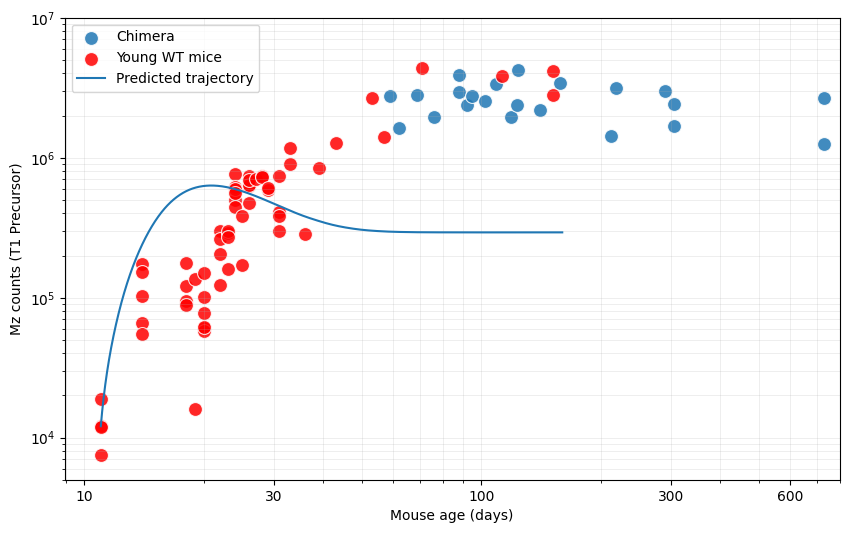

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
plt.plot(t_ev, sol_1.y[0], label='Predicted trajectory')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
def P(t):
    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))


def delta_dd(M):
    delta = 0.009
    size = 33292
    delta_dd =  delta * (1 + (M/size))
    return delta_dd

# Define the ODE function
def ode_function(t, M, phi, rho, delta_dd, P):
    dMdt = phi * P(t) + rho * M - delta_dd(M) * M
    return np.array(dMdt)

phi = 0.014 #Influx rate
rho = 0.019  #Division rate
# delta = 0.028 #Death rate

#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [12058]

t_ev = np.arange(11, 160, 0.001)


sol_1 = solve_ivp(ode_function, [11, 160], M0, t_eval=t_ev, args=(phi, rho, delta_dd, P))
print(sol_1.y)

[[ 12058.          12092.68681142  12127.39819848 ... 290883.10156521
  290883.09289394 290883.08421305]]


/tmp/ipykernel_2586026/2534866978.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


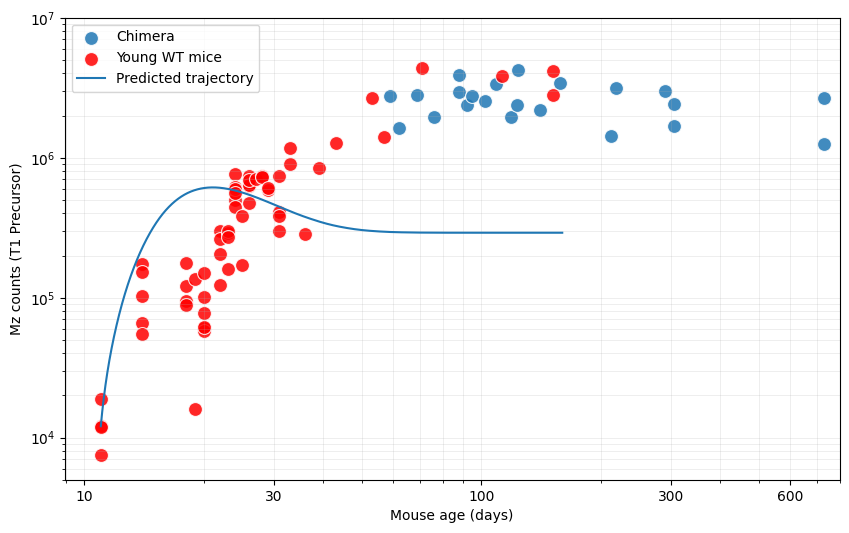

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
plt.plot(t_ev, sol_1.y[0], label='Predicted trajectory')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
def P(t):
    theta_0 = np.exp(14.17)
    nu = 0.31
    n = 1.98
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def phi(t):
    r_phi = 1.25
    phi = 0.015
    phi_var =  ((phi - 0.0019) / (1 + np.exp(-(r_phi) * (t-20)))) +0.0019
    return phi_var


# Define the ODE function
def ode_function(t, M, phi, rho, P):
    dMdt = phi(t) * P(t) + rho * M - delta * M
    return np.array(dMdt)

# def phi(t):
#     if(t < 40):
#     #  r_phi = 0.02
#     #  phi = 0.014
#     #  phi_var =  phi * (1 - np.exp(-(r_phi) * (t-10)**1.7))
#      r_phi = 0.02
#      phi = 0.014
#      phi_var =  phi / (1 + np.exp(-(r_phi) * (t-10)))
#     return(phi_var)


rho = 0.015  #Division rate
delta = 0.024 #Death rate

#Initial conditions at time t=11
# M0 = np.array([np.mean(data_neutral.y0)*(np.mean(data_neutral.kappa_0)) + np.mean(data_neutral.y0)*(1-np.mean(data_neutral.kappa_0))])
M0 = [12058]

t_ev = np.arange(11, 750, 0.001)


sol_1 = solve_ivp(ode_function, [11, 750], M0, t_eval=t_ev, args=(phi, rho, delta_dd, P))
print(sol_1.y)
print(np.mean(data_neutral.delta))
print(np.mean(data_neutral.size_dens))

TypeError: ode_function() takes 5 positional arguments but 6 were given

/tmp/ipykernel_1802502/2960672019.py:9: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


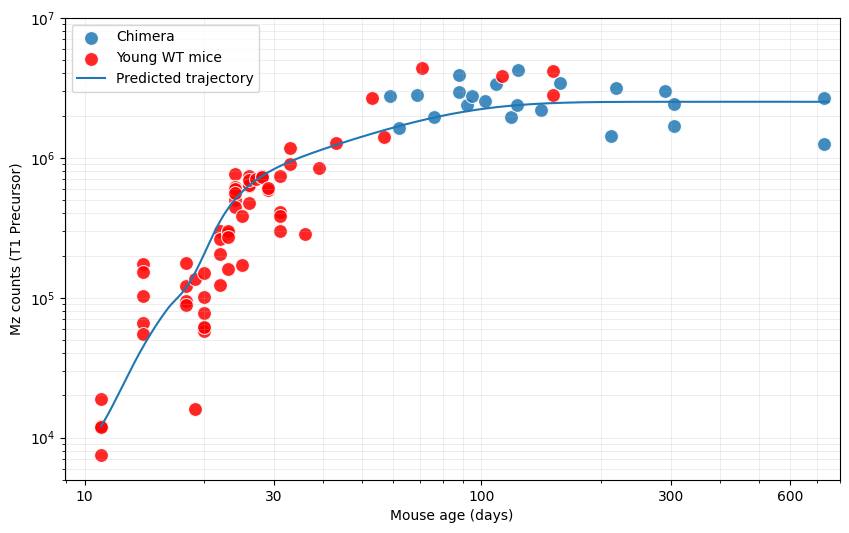

In [ ]:
# Plot the Mz counts
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=100, label='Chimera', legend=False)
sns.scatterplot(data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
plt.plot(t_ev, sol_1.y[0], label='Predicted trajectory')
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(0, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Mz counts (T1 Precursor)')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.legend()
plt.show()


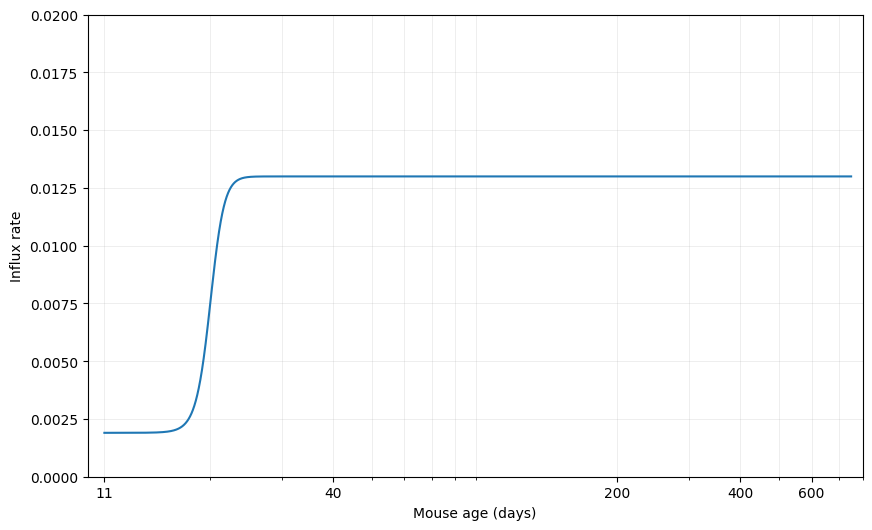

In [ ]:
#Daily Influx from T1 TO Mz
# Plot phi(t)

fig = plt.figure(figsize=(10, 6))
plt.plot(t_ev, phi(t_ev))
plt.xscale('log')
# plt.yscale('log')
plt.xlim(10, 800)
plt.ylim(0, 0.02)
plt.xticks([11, 40, 200, 400, 600], [11, 40, 200, 400, 600])
plt.xlabel('Mouse age (days)')
plt.ylabel('Influx rate')
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.show()

